## 1. Import libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

## 2. Load dataset

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()


## 3. Class Names

In [3]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print("Class 0:", class_names[0])
print("Class 7:", class_names[7])

Class 0: T-shirt/top
Class 7: Sneaker


## 4. Normalization

In [4]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.

print("Minimum pixel value in x_train:", x_train.min())
print("Maximum pixel value in x_train:", x_train.max())

Minimum pixel value in x_train: 0.0
Maximum pixel value in x_train: 1.0


## 5. Add channel dimension

In [5]:
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

print(x_train.shape)

(60000, 28, 28, 1)


## 6. Build CNN model

In [6]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(50, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model.summary()

c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 50)     │        14,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 50)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1250)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       160,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 176,188 (688.23 KB)

 Trainable params: 176,188 (688.23 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Compile model

In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 8. Train model

In [8]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.7071 - loss: 0.8129 - val_accuracy: 0.8638 - val_loss: 0.3769
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.8611 - loss: 0.3846 - val_accuracy: 0.8802 - val_loss: 0.3198
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.8846 - loss: 0.3208 - val_accuracy: 0.8890 - val_loss: 0.2937
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.8923 - loss: 0.2941 - val_accuracy: 0.8940 - val_loss: 0.2817
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.8995 - loss: 0.2709 - val_accuracy: 0.9035 - val_loss: 0.2577


## 9. Evaluate model

In [9]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)
print("Test loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9059 - loss: 0.2696
Test accuracy: 0.9024999737739563
Test loss: 0.2706283926963806


## 10. Make Predictions

In [10]:
# Predict the class probabilities for the test set
predictions = model.predict(x_test)

# Example: prediction for the first test image
print("Probabilities for first test image:")
print(predictions[0])

# Predicted class index = position of the highest probability
predicted_label = tf.argmax(predictions[0]).numpy()

print("Predicted label index:", predicted_label)
print("Predicted class name:", class_names[predicted_label])
print("Actual class name:", class_names[y_test[0]])


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Probabilities for first test image:
[9.5489185e-08 3.3890146e-08 2.1642792e-08 1.3430805e-08 1.4238151e-09
 1.7529092e-04 3.9979682e-08 8.7199576e-04 5.2483057e-07 9.9895191e-01]
Predicted label index: 9
Predicted class name: Ankle boot
Actual class name: Ankle boot


## 11. View Sample image

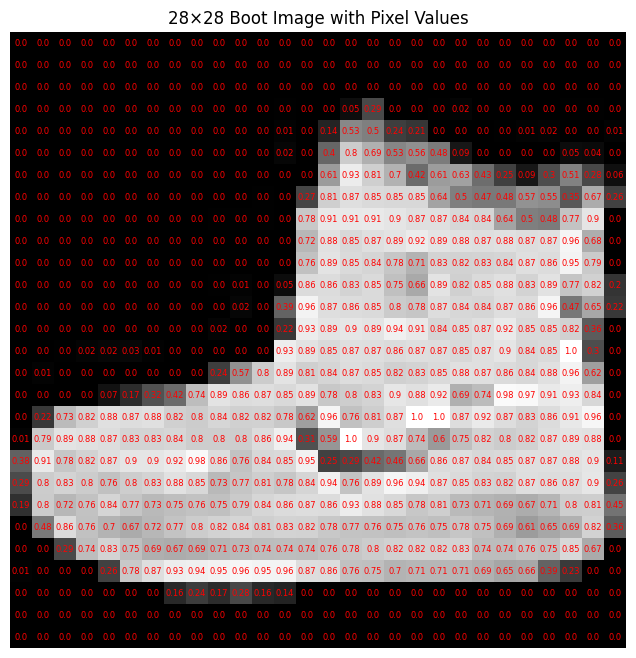

In [11]:
import matplotlib.pyplot as plt
 
# Select one image (example: index 0)
img = x_train[0].squeeze()
 
plt.figure(figsize=(8,8))
plt.imshow(img, cmap="gray")
 
# Overlay pixel values
for i in range(28):
    for j in range(28):
        plt.text(j, i,
                 round(img[i, j], 2),   # show normalized value
                 ha="center",
                 va="center",
                 color="red",
                 fontsize=6)
 
plt.title("28×28 Boot Image with Pixel Values")
plt.axis("off")
plt.show()